## Plot Total Mineral Column

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import matplotlib.pyplot as plt
from pathlib import Path
import dill
import matplotlib.lines as mlines
import re

In [2]:
data = {}

for d in Path("../ModelOutputs/MineralSoil/").glob("VWC_*.dill"):
    with open(d, "rb") as f:
        out = dill.load(f)

    data[d.stem] = out   

In [3]:
first_key = list(data.keys())[0]
out = data[first_key]

In [4]:
T_dfs = {}

for run_name, out in data.items():
    try:
        # extract theta1 from filename
        m = re.search(r"th1_(\d+\.\d+)", run_name)
        th1 = float(m.group(1))*100   # keep as float (0.10, 0.50, etc.)

        # build dataframe
        df = pd.DataFrame(
            out.T,
            columns=out.z,   # real depths (much better than Depth_0 etc.)
            index=out.t
        )
        # store
        T_dfs[f"df_{th1:.0f}"] = df

    except Exception as e:
        print(f"Skipped {run_name}: {e}")

In [5]:
J_dfs = {}

for run_name, out in data.items():
    try:
        # extract theta1 from filename
        m = re.search(r"th1_(\d+\.\d+)", run_name)
        th1 = float(m.group(1))*100   # keep as float (0.10, 0.50, etc.)

        # build dataframe
        df = pd.DataFrame(
            out.jT,   # real depths (much better than Depth_0 etc.)
            index=out.t
        )
        # store
        J_dfs[f"df_{th1:.0f}"] = df

    except Exception as e:
        print(f"Skipped {run_name}: {e}")

In [6]:
def fake_date(df):
    dfe = df.iloc[74:].reset_index(drop = True)
    n = len(dfe)
    dates = pd.date_range("2000-01-01", periods=n, freq="D")
    dfe.index = dates
    return dfe

In [7]:
# apply fake date to all dataframes and changes them in dictionary
T_dfse = {}
T_dfse = {key: fake_date(df) for key, df in T_dfs.items()}

In [8]:
# apply fake date to all dataframes and changes them in dictionary
J_dfse = {}
J_dfse = {key: fake_date(df) for key, df in J_dfs.items()}

In [9]:
# Define mesh
nz=1500
dz=np.zeros(nz)+0.01
dz[0:1000] = 0.01 # 0 -5
dz[1000:1500] = 0.02 # 5m - 10m
bz=np.hstack([0, np.cumsum(dz)])
z=(bz[:-1]+bz[1:])/2
zMax=bz[-1]

In [10]:
def depths(df,z):
    z1 = np.round(z, 3)
    df.columns = z1
    return df

In [11]:
# apply depths to all the dataframes
T_dfs = {key: depths(df,z) for key, df in T_dfs.items()}
T_dfse = {key: depths(df,z) for key, df in T_dfse.items()}

In [12]:
def depths(df):
    z1 = np.round(z, 3)
    df.columns = z1
    return df

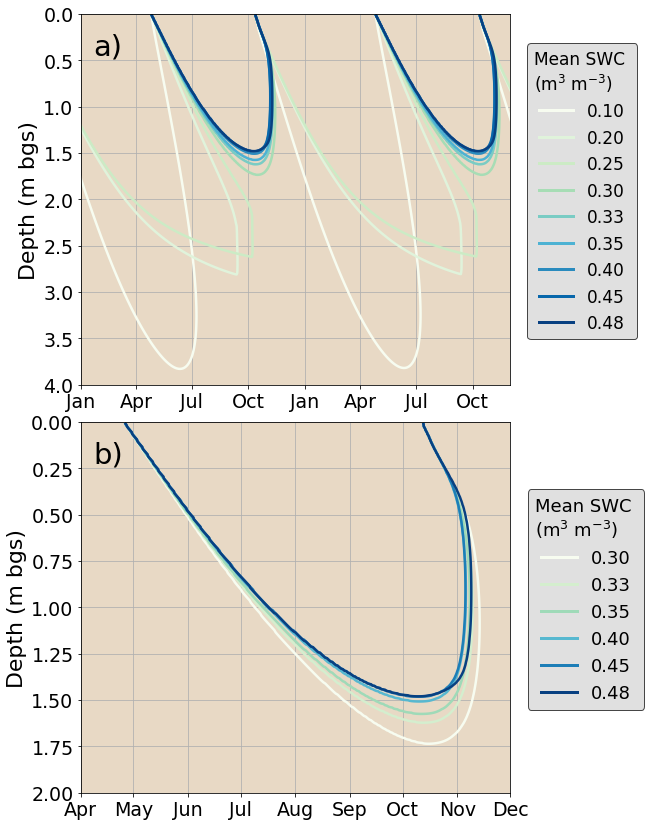

In [13]:
# --- Datasets and labels ---
datasets = (T_dfse['df_10'],T_dfse['df_20'],T_dfse['df_25'],T_dfse['df_30'],T_dfse['df_33'],T_dfse['df_35'],T_dfse['df_40'],T_dfse['df_45'],T_dfse['df_48'])
labels = ('0.10','0.20','0.25','0.30','0.33','0.35','0.40','0.45','0.48')

# --- Plot ---`
fig, ax = plt.subplots(2, 1,figsize=(9, 12))

ax[0].axhspan(0.0, 5, color='tan', alpha=0.5)

    
# --- Generate progressively darker blue colors (light to dark) ---
blues = plt.cm.GnBu(np.linspace(0., 1, len(datasets)))  # 0.3 = light, 1.0 = dark
for data, vwc, color in zip(datasets, labels, blues):

    # For VWC >= 0.30, only allow contours in upper 2 m
    if float(vwc) >= 0.30:
        data_plot = data.loc[:, data.columns.astype(float) <= 2.0]
    else:
        data_plot = data

    Time, Depth = np.meshgrid(
        data_plot.index,
        data_plot.columns.astype(float),
        indexing='ij'
    )

    ax[0].contour(
        Time,
        Depth,
        data_plot.values,
        levels=[0],
        colors=[color],
        linewidths=2.5
    )
    
# --- Make custom legend lines ---
legend_lines = [
    mlines.Line2D([], [], color=color, lw=3, label=label)
    for color, label in zip(blues, labels)
]
ax[0].invert_yaxis()
ax[0].set_ylabel("Depth (m bgs)", fontsize = 22)
#ax.set_xlim(3450, 3750)
ax[0].set_ylim(4, 0)
ax[0].tick_params(axis='both', labelsize=19) 
ax[0].grid()

# --- Add legend ---
leg = ax[0].legend(
    handles=legend_lines,
    loc='lower left',
    bbox_to_anchor=(1.02, 0.1),
    fontsize=17,
    title='Mean SWC \n(m$^3$ m$^{-3}$)',
    title_fontproperties={'size': 17}
)
leg.get_frame().set_facecolor('lightgrey')
leg.get_frame().set_alpha(0.7) 
leg.get_frame().set_edgecolor('black')

start_date = pd.to_datetime('2001-01-01')
end_date = pd.to_datetime('2002-12')
ax[0].set_xlim(start_date, end_date)
ax[0].xaxis.set_major_formatter(pl.matplotlib.dates.DateFormatter('%b'))
ax[0].text(
    0.03, 0.95,
    "a)",
    transform=ax[0].transAxes,
    fontsize=29,
    va='top')
##––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––##

datasets2 = (T_dfse['df_30'],T_dfse['df_33'],T_dfse['df_35'],T_dfse['df_40'],T_dfse['df_45'],T_dfse['df_48'])
labels2 = ('0.30','0.33','0.35','0.40','0.45','0.48')

ax[1].axhspan(0.0, 5, color='tan', alpha=0.5)
blues2 = plt.cm.GnBu(np.linspace(0., 1, len(datasets2)))  # 0.3 = light, 1.0 = dark

for data, color in zip(datasets2, blues2):
    Time, Depth = np.meshgrid(data.index, data.columns, indexing='ij')
    ax[1].contour(Time, Depth, data.values, levels=[0], colors=[color], linewidths=2.5)
# --- Make custom legend lines ---
legend_lines = [
    mlines.Line2D([], [], color=color, lw=3, label=label)
    for color, label in zip(blues2, labels2)]
ax[1].invert_yaxis()
ax[1].set_ylabel("Depth (m bgs)", fontsize = 22)
#ax.set_xlim(3450, 3750)
ax[1].set_ylim(2, 0)
ax[1].tick_params(axis='both', labelsize=19) 
ax[1].grid()

# --- Add legend ---

leg2 = ax[1].legend(
    handles=legend_lines,
    loc='lower left',
    bbox_to_anchor=(1.02, 0.2),
    fontsize=18,
    title='Mean SWC \n(m$^3$ m$^{-3}$)',
    title_fontproperties={'size': 18})

leg2.get_frame().set_facecolor('lightgrey')
leg2.get_frame().set_alpha(0.7) 
leg2.get_frame().set_edgecolor('black')
start_date2 = pd.to_datetime('2002-04-01')
end_date2 = pd.to_datetime('2002-12')
ax[1].set_xlim(start_date2, end_date2)
ax[1].xaxis.set_major_formatter(pl.matplotlib.dates.DateFormatter('%b'))
ax[1].text(
    0.03, 0.95,
    "b)",
    transform=ax[1].transAxes,
    fontsize=29,
    va='top')   
    
fig.tight_layout()
fig.subplots_adjust(hspace=0.1)

In [14]:
dfs = [T_dfs['df_10'],T_dfs['df_20'],T_dfs['df_25'],T_dfs['df_30'],T_dfs['df_33'],T_dfs['df_35'],T_dfs['df_40'],T_dfs['df_45'],T_dfs['df_48']]

In [15]:
def surface_thaw_depth(row, depths):
    vals = row.values.astype(float)

    # If surface is frozen, no active-layer thaw
    if vals[0] < 0:
        return 0.0

    # Find first frozen point below the surface
    frozen = np.where(vals < 0)[0]

    if len(frozen) == 0:
        return depths[-1]

    i = frozen[0]

    # First point is frozen
    if i == 0:
        return 0.0

    # Linear interpolation to 0°C crossing
    T1, T2 = vals[i-1], vals[i]
    z1, z2 = depths[i-1], depths[i]

    z0 = z1 + (0 - T1) * (z2 - z1) / (T2 - T1)

    return z0

In [16]:
def equilibriated(df, start=900, end=1450, tol=0.01):

    depths = df.columns.astype(float).values
    L = end - start

    # ---- Last year ----
    sub1 = df.iloc[start:end]

    thaw1 = sub1.apply(
        lambda row: surface_thaw_depth(row, depths),
        axis=1
    )

    d1 = thaw1.max()

    # ---- Previous year ----
    sub2 = df.iloc[start-L:start]

    thaw2 = sub2.apply(
        lambda row: surface_thaw_depth(row, depths),
        axis=1
    )

    d2 = thaw2.max()

    # ---- Compare ----
    diff = abs(d1 - d2)

    if diff <= tol:
        print(
            f"Equilibrated: {d1:.3f} vs {d2:.3f} "
            f"(diff = {diff:.4f})"
        )
    else:
        print(
            f"Different: {d1:.3f} vs {d2:.3f} "
            f"(diff = {diff:.4f})"
        )

    return d1, d2

In [17]:
for df in dfs:
    equilibriated(df)

Equilibrated: 19.990 vs 19.990 (diff = 0.0000)
Equilibrated: 19.990 vs 19.990 (diff = 0.0000)
Equilibrated: 19.990 vs 19.990 (diff = 0.0000)
Equilibrated: 1.731 vs 1.731 (diff = 0.0004)
Equilibrated: 1.622 vs 1.623 (diff = 0.0008)
Equilibrated: 1.575 vs 1.575 (diff = 0.0008)
Equilibrated: 1.508 vs 1.508 (diff = 0.0008)
Equilibrated: 1.482 vs 1.483 (diff = 0.0008)
Equilibrated: 1.480 vs 1.481 (diff = 0.0009)


In [18]:
dfs = [T_dfs['df_20'],T_dfs['df_25'],T_dfs['df_30'],T_dfs['df_30'],T_dfs['df_35'], T_dfs['df_40'], T_dfs['df_45'], T_dfs['df_48']]

In [20]:
VWC = [0.30, 0.33, 0.35, 0.40, 0.45, 0.48]
ALT = [1.731, 1.623, 1.575, 1.508, 1.483, 1.481]

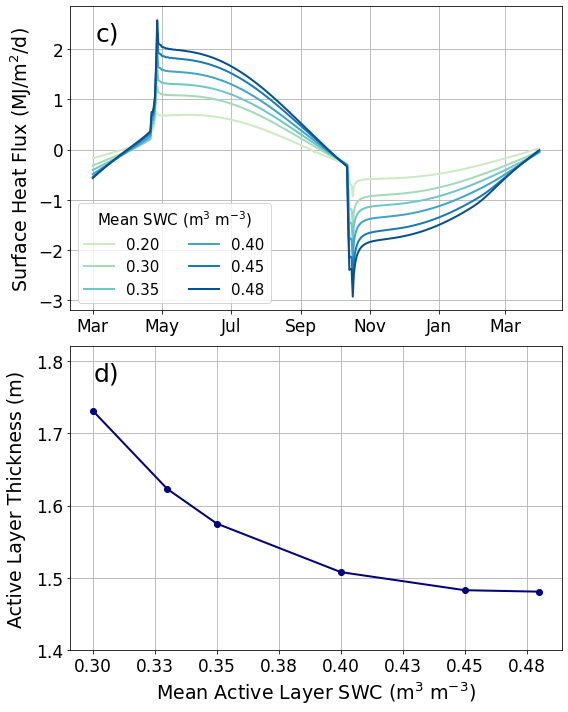

In [21]:
fig, ax = pl.subplots(2, 1, figsize=(8, 10))

a = '2001-03'
b = '2002-03'

# ---------- TOP PANEL (unchanged) ----------

ax[1].plot(
    VWC, ALT,
    label='0.60',
    color='navy',
    linewidth=2, marker = 'o'
)
#ax[0].set_ylim(-1,0.05)
ax[0].xaxis.set_major_formatter(pl.matplotlib.dates.DateFormatter('%b'))

# ---------- BOTTOM PANEL (GnBu gradient) ----------

# J datasets and labels (ordered low → high VWC)
J_datasets = (
    J_dfse['df_20'].loc[a:b] / 1e6,
    J_dfse['df_30'].loc[a:b] / 1e6,
    J_dfse['df_35'].loc[a:b] / 1e6,
    J_dfse['df_40'].loc[a:b] / 1e6,
    J_dfse['df_45'].loc[a:b] / 1e6,
    J_dfse['df_48'].loc[a:b] / 1e6,)

J_labels = ('0.20','0.30','0.35','0.40','0.45','0.48')

# Light → dark GnBu
gnbu = pl.cm.GnBu(np.linspace(0.25, 0.95, len(J_datasets)))

for data, label, color in zip(J_datasets, J_labels, gnbu):
    ax[0].plot(data, label=label, color=color, linewidth=2)

ax[0].xaxis.set_major_formatter(pl.matplotlib.dates.DateFormatter('%b'))

# ---------- LEGENDS & LABELS ----------
ax[0].legend(
    fontsize=15,
    loc='lower left',
    title='Mean SWC (m$^3$ m$^{-3}$)',
    title_fontsize=15, ncol = 2)

ax[0].set_ylabel('Surface Heat Flux (MJ/m$^2$/d)', fontsize=19)
ax[1].set_ylabel('Active Layer Thickness (m)', fontsize=19, labelpad=10)

ax[0].tick_params(axis='both', labelsize=17)
ax[1].tick_params(axis='both', labelsize=17)

fig.subplots_adjust(hspace=0.1)

# ---------- PANEL LABELS ----------
ax[0].text(
    0.1, 0.87, "c)",
    transform=ax[0].transAxes,
    fontsize=25,
    ha="right",
    va="bottom")

ax[1].text(
    0.1, 0.87, "d)",
    transform=ax[1].transAxes,
    fontsize=25,
    ha="right",
    va="bottom")

ax[1].set_ylim(1.4,1.82)
#ax[1].set_ylim(1.3,0)
ax[1].set_xlabel('Mean Active Layer SWC (m$^3$ m$^{-3}$)', fontsize = 19)
from matplotlib.ticker import FormatStrFormatter

ax[1].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

pl.tight_layout()
ax[0].grid()
ax[1].grid()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# ============================================================
# SETTINGS YOU MAY WANT TO CHANGE
# ============================================================

water_contents = ['df_30', 'df_40','df_45']
titles = ['SWC = 0.30', 'SWC = 0.40', 'SWC = 0.45']

# Common middle depth
a = 0.9
# Temperatures to plot in each row
plot_depths = [
    [0.40, a, 1.731],   # SWC 0.30
    [0.40, a, 1.575],   # SWC 0.35
    [0.40, a, 1.483]]    # SWC 0.45]

# Depth used to calculate the shaded zero-curtain period
shade_depths = [a,   a,   a ]
# Temperature range for LEFT contour shading
contour_lower = -0.05
contour_upper = 0.0

# Temperature range used for RIGHT zero-curtain shading
shade_lower = -0.05
shade_upper = 0.0

# Date ranges
start_date = pd.to_datetime('2002-03-01')
end_date = pd.to_datetime('2003-05-01')

freeze_start = pd.Timestamp('2002-09-01')
freeze_end = pd.Timestamp('2003-06-01')

# Line colors for temperature depths
colors = ['green', 'purple', 'blue']

# ============================================================
# FIGURE
# ============================================================
fig, ax = plt.subplots(
    3, 2,
    figsize=(14, 14),
    gridspec_kw={'width_ratios': [1.1, 1]},
    sharex='col')
# ============================================================
# LOOP THROUGH WATER CONTENTS
# ============================================================
for i, (wc, title) in enumerate(zip(water_contents, titles)):

    data = T_dfse[wc]
    depth_cols = data.columns.astype(float)

    Time, Depth = np.meshgrid(
        data.index,
        depth_cols,
        indexing='ij')
    # ========================================================
    # LEFT PANEL: ISOTHERMS
    # ========================================================

    left = ax[i, 0]
    # Background soil shading
    left.axhspan(
        0,
        5,
        color='tan',
        alpha=0.5)

    # Temperature-zone shading
    left.contourf(
        Time,
        Depth,
        data.values,
        levels=[contour_lower, contour_upper],
        colors=['lightskyblue'],
        alpha=0.6)

    # Isotherm lines
    left.contour(
        Time,
        Depth,
        data.values,
        levels=[contour_lower, contour_upper],
        colors='navy',
        linestyles=['--', '-'],
        linewidths=1.5)

    left.invert_yaxis()
    left.set_ylim(3, 0)
    left.set_xlim(start_date, end_date)
    left.set_ylabel(
        "Depth (m bgs)",
        fontsize=17)
    left.set_title(
        title,
        fontsize=18)
    left.tick_params(
        axis='both',
        labelsize=15)
    left.grid(alpha=0.3)
    # ========================================================
    # RIGHT PANEL: TEMPERATURE
    # ========================================================
    right = ax[i, 1]

    for d, c in zip(plot_depths[i], colors):

        # Find closest model depth that is <= requested depth
        valid = np.where(depth_cols <= d)[0]
        col = valid[-1]

        actual_depth = depth_cols[col]
        temp = data.iloc[:, col]

        right.plot(data.index, temp, color=c, lw=2, label=f'{actual_depth:.2f} m')
        # ========================================================
        # TEMPERATURE SERIES USED FOR SHADING
    # ========================================================

    shade_depth = shade_depths[i]

    shade_col = np.argmin(
        np.abs(depth_cols - shade_depth))

    actual_shade_depth = depth_cols[shade_col]
    temp_shade = data.iloc[:, shade_col]

    print(
        f'{title}: shading based on '
        f'{actual_shade_depth:.3f} m')

    # Identify times in selected temperature range
    mask = (
        (temp_shade.index >= freeze_start) &
        (temp_shade.index <= freeze_end) &
        (temp_shade <= shade_upper) &
        (temp_shade >= shade_lower))

    days_in_range = mask.sum()

    print(
        f'{title}: {days_in_range} days between '
        f'{shade_lower} and {shade_upper} °C')

    # ========================================================
    # SHADE CONTINUOUS PERIODS
    # ========================================================

    in_region = False

    for j in range(len(mask)):

        if mask.iloc[j] and not in_region:

            start = temp_shade.index[j]
            in_region = True

        elif not mask.iloc[j] and in_region:

            right.axvspan(
                start,
                temp_shade.index[j - 1],
                color='purple',
                alpha=0.2,
                zorder=0)
            in_region = False

    # If final shaded region reaches end of series
    if in_region:

        right.axvspan(
            start,
            temp_shade.index[-1],
            color='purple',
            alpha=0.2,
            zorder=0)

    # ========================================================
    # RIGHT PANEL FORMATTING
    # ========================================================

    right.set_xlim(
        start_date,
        end_date)

    right.set_ylabel(
        "Temperature (°C)",
        fontsize=17 )

    right.tick_params(
        axis='both',
        labelsize=15 )

    right.grid(alpha=0.3)
    # Sort legend entries by depth
    handles, legend_labels = right.get_legend_handles_labels()
    order = np.argsort(
        [
            float(label.split()[0])
            for label in legend_labels])
    right.legend(
        [handles[j] for j in order],
        [legend_labels[j] for j in order],
        title="Depth",
        fontsize=12,
        title_fontsize=13,
        loc='best',
        framealpha=0.8)
# ============================================================
# ISOTHERM LEGEND
# ============================================================

isotherm_line1 = Line2D(
    [0], [0],
    color='navy',
    lw=2,
    linestyle='-',
    label='0°C Isotherm')

isotherm_line2 = Line2D(
    [0], [0],
    color='navy',
    lw=2,
    linestyle='--',
    label=f'{contour_lower:.2f}°C Isotherm')

ax[0, 0].legend(
    handles=[
        isotherm_line1,
        isotherm_line2
    ],
    ncol=2,
    fontsize=15,
    frameon=True,
    loc='lower left')

# ============================================================
# PANEL LABELS
# ============================================================

panel_labels = [
    'a)', 'b)',
    'c)', 'd)',
    'e)', 'f)']

for a_ax, label in zip(
    ax.flatten(),
    panel_labels):

    a_ax.text(
        0.03,
        0.95,
        label,
        transform=a_ax.transAxes,
        fontsize=25,
        va='top')
# ============================================================
# X-AXIS FORMATTING
# ============================================================
for a_ax in ax.flatten():

    a_ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b'))

# Optional:
# ax[2, 1].set_ylim(-0.04, 0.00)
# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.97])

plt.subplots_adjust(
    hspace=0.15,
    wspace=0.25)
plt.savefig(
    './Images/Revision/IsothermRange2Mineral_Shaded.png',
    dpi=500,
    bbox_inches='tight'
)

plt.show()